# EXPLORATORY DATA ANALYSIS 1

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

## TAKEN FROM https://stats.stackexchange.com/questions/403652/two-sample-quantile-quantile-plot-in-python
## Solution provided by user: Artem Mavrin
def qqplot(x, y, quantiles=None, interpolation='nearest', ax=None, rug=False,
           rug_length=0.05, rug_kwargs=None, **kwargs):
    """Draw a quantile-quantile plot for `x` versus `y`.

    Parameters
    ----------
    x, y : array-like
        One-dimensional numeric arrays.

    ax : matplotlib.axes.Axes, optional
        Axes on which to plot. If not provided, the current axes will be used.

    quantiles : int or array-like, optional
        Quantiles to include in the plot. This can be an array of quantiles, in
        which case only the specified quantiles of `x` and `y` will be plotted.
        If this is an int `n`, then the quantiles will be `n` evenly spaced
        points between 0 and 1. If this is None, then `min(len(x), len(y))`
        evenly spaced quantiles between 0 and 1 will be computed.

    interpolation : {‘linear’, ‘lower’, ‘higher’, ‘midpoint’, ‘nearest’}
        Specify the interpolation method used to find quantiles when `quantiles`
        is an int or None. See the documentation for numpy.quantile().

    rug : bool, optional
        If True, draw a rug plot representing both samples on the horizontal and
        vertical axes. If False, no rug plot is drawn.

    rug_length : float in [0, 1], optional
        Specifies the length of the rug plot lines as a fraction of the total
        vertical or horizontal length.

    rug_kwargs : dict of keyword arguments
        Keyword arguments to pass to matplotlib.axes.Axes.axvline() and
        matplotlib.axes.Axes.axhline() when drawing rug plots.

    kwargs : dict of keyword arguments
        Keyword arguments to pass to matplotlib.axes.Axes.scatter() when drawing
        the q-q plot.
    """
    import numbers
    import numpy as np
    # Get current axes if none are provided
    if ax is None:
        ax = plt.gca()

    if quantiles is None:
        quantiles = min(len(x), len(y))

    # Compute quantiles of the two samples
    if isinstance(quantiles, numbers.Integral):
        quantiles = np.linspace(start=0, stop=1, num=int(quantiles))
    else:
        quantiles = np.atleast_1d(np.sort(quantiles))
    x_quantiles = np.quantile(x, quantiles, interpolation=interpolation)
    y_quantiles = np.quantile(y, quantiles, interpolation=interpolation)

    minimum=np.min([np.min(x),np.min(y)])
    maximum=np.max([np.max(x),np.max(y)])

    # Draw the rug plots if requested
    if rug:
        # Default rug plot settings
        rug_x_params = dict(ymin=0, ymax=rug_length, c='gray', alpha=0.5)
        rug_y_params = dict(xmin=0, xmax=rug_length, c='gray', alpha=0.5)

        # Override default setting by any user-specified settings
        if rug_kwargs is not None:
            rug_x_params.update(rug_kwargs)
            rug_y_params.update(rug_kwargs)

        # Draw the rug plots
        for point in x:
            ax.axvline(point, **rug_x_params)
        for point in y:
            ax.axhline(point, **rug_y_params)

    # Draw the q-q plot
    ax.scatter(x_quantiles, y_quantiles, **kwargs)
    ax.axline([minimum, minimum], [maximum, maximum], color='k')

Mount google drive

In [9]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_ROOT = '/content/drive/MyDrive/path'
    print('Google Drive montato in Colab.')
except ModuleNotFoundError:
    DATA_ROOT = '.'
    print('Ambiente locale rilevato: google.colab non disponibile, salto il mount di Drive.')

Ambiente locale rilevato: google.colab non disponibile, salto il mount di Drive.


Use Kaggle username and key

In [10]:
import os
os.environ['KAGGLE_USERNAME'] = 'BDA'
os.environ['KAGGLE_KEY'] = 'KGAT_3f3ceca6c3fc64f2daf6a7f63a5fd0ed'


In [11]:
!pip install kaggle

In [12]:
os.chdir('/content/drive/Big_Data/Exploratory/')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/Big_Data/Exploratory/'

In [ ]:
!kaggle competitions download -c titanic
!unzip /content/drive/MyDrive/Colab_Notebooks/BDA/titanic.zip

In [ ]:
import pandas as pd
#Questo se siete collegati al colab
#df=pd.read_csv('/content/drive/MyDrive/path/train.csv')
#Altrimenti
df = pd.read_csv('train.csv')
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Excercise:

* Consider the columns ['Survived',	'Pclass', 'Sex',	'Age',	'SibSp',	'Parch', 'Fare', Embarked']. Also said: ignore ['Ticket','Cabin'].
* Plot the distribution of the previous features using histograms (numerical, ordinal) or barplot (nominal or ordinal).  Mind that showing the barplot of nominal attributes requires first to get their value_counts distribution using: df['nominal_attribute'].value_counts().plot(kind='bar').
* Understand what may be the best option for measuring attribute centrality and dispersion (if needed) and compute them.
* Use a box plot to summarize the 'Fare' attribute. Do it again but grouping by the 'Survived' outcome. Does money buy safety (at least to some degree)?
* Split the dataset into Male and Female passengers and display a qq-plot of the 'Fare' attribute comparing the two groups. What does it mean? Is it possible to find a simple reason why this is the result or not?
* Plot a stratified barplot: the barplot should have on the x axis the 'Embarked' attribute and be stratified by the 'Pclass' attribute. Given that C = Cherbourg (France) , Q = Queenstown (Ireland), S = Southampton (UK); which city had the highest percentage of emigrants from the lower social classes?
* Check whether  the 'Survived' attribute is correlated with 'Pclass' or 'Sex'.
* Define a new attribute 'Children' (choose an Age threshold) and compute its correlation with 'Survival'.
* Check whether the 'Survived' attribute is correlated with 'Age', 'Fare', 'SibSp', or	'Parch'.
* Display a scatterplot between "Age" and "Fare" and compute correlation between them using multiple methods. Was the computation of correlation really needed in this case?

Hints:
* quantiles of an attribute ca be computed using df['Attribute'].quantile(q)
* stratified bar plot should not be directly applied to the dataframe. Think about the ingredients needed to create it and give a look that the pandas.crosstab function at https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html


In [ ]:
df['Survived'].value_counts().plot(kind='bar', title='People who survived.')
#Dato che è un valore nominale possiamo usare solo la moda come misura di centralità.
print(df['Survived'].mode())

In [ ]:
#df.plot.hist(column='Pclass')
#É un valore ordinale e indica la classe del biglietto, possiamo usare mediana e moda.
print(df['Pclass'].median())
#Ora dobbiamo stampare la misura di dispersione della classe Pclass, possiamo usare i quantili.
print(df['Pclass'].quantile([0.25, 0.5, 0.75]))
#Possiamo stampare anche il boxplot
df.boxplot(column='Pclass')

In [ ]:
df['Sex'].value_counts().plot.bar(x='Sex', title="Sex distribution.")

#Confermiamo che erano più i maschi a bordi del titanic
print(df['Sex'].mode())


In [ ]:
df.plot.hist(column='Age')
#Notiamo che come ci si poteva aspettare l'età ha una distribuzione con dei picchi tra i 20-30 anni mentre agli estremi risultano essere
#sempre meno i partecipanti. Solitamente infatti ha una distribuzione a campana.

print(df['Age'].mean())

#Ora misuriamo la dispersione con la deviazione standard e la varianza
print(df['Age'].std())
print(df['Age'].var())

In [ ]:
df['SibSp'].value_counts().plot.bar(x="SibSp", title="SibSp Distribution.")

#Questa variabile indica il numero di fratelli/sorelle/coniugi a bordo
print(df['SibSp'].mean())
print(df['SibSp'].std())
print(df['SibSp'].var())

In [ ]:
df.plot.hist(column='Parch')
print(df['Parch'].mean())
print(df['Parch'].std())
print(df['Parch'].var())

In [ ]:
df['Fare'].value_counts().plot.bar(x='Fare', title='Fare distribution.')
print(df['Fare'].mean())
print(df['Fare'].std())
print(df['Fare'].var())

In [ ]:
df.plot.hist(column='Fare')

In [ ]:
df['Embarked'].value_counts().plot.bar(x='Embarked', title="Embarked distribution")
print(df['Embarked'].mode())

<Axes: >

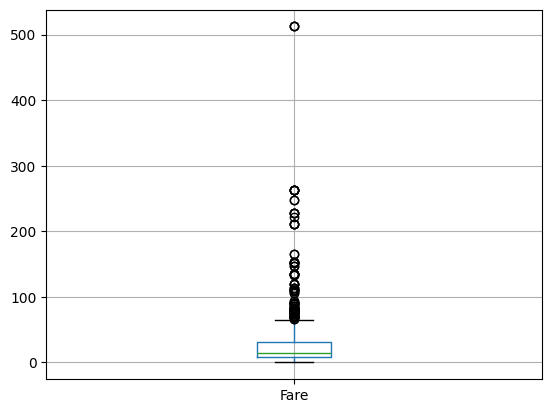

In [ ]:
#Lookin at this we can see that there are a lot of outliers but we cannot 
#properly define which survived and which not.


df.boxplot(column='Fare')

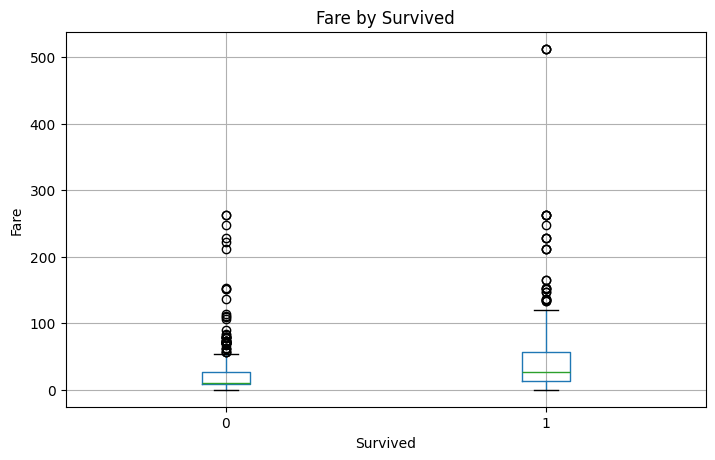

In [ ]:
#Just by looking at this plot we can see that who survived paid a more expensive 
#ticket bill.
#This implicitly define that buying a higher price ticket can lead to a much higher 
#survival rate.

import matplotlib.pyplot as plt

ax = df.boxplot(column='Fare', by='Survived', figsize=(8, 5))
plt.suptitle('')
ax.set_title('Fare by Survived')
ax.set_xlabel('Survived')
ax.set_ylabel('Fare')
plt.show()

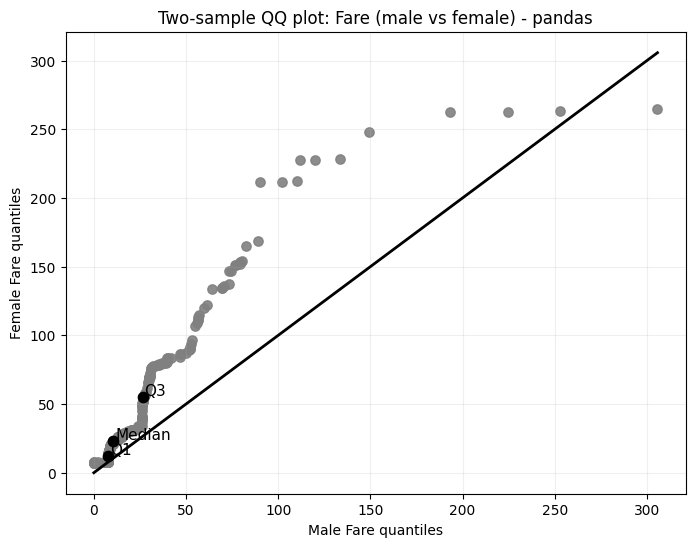

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Seleziona le due serie
male_fare = df.loc[df["Sex"] == "male", "Fare"].dropna()
female_fare = df.loc[df["Sex"] == "female", "Fare"].dropna()

# 2) Quantili comuni con pandas (anche se le cardinalita sono diverse)
nq = min(len(male_fare), len(female_fare))
q = pd.Series(range(1, nq + 1), dtype="float64") / (nq + 1)

male_q = male_fare.quantile(q).reset_index(drop=True)
female_q = female_fare.quantile(q).reset_index(drop=True)

qq_df = pd.DataFrame({
    "male_q": male_q,
    "female_q": female_q
})

# 3) Scatter QQ con pandas
ax = qq_df.plot.scatter(
    x="male_q",
    y="female_q",
    color="gray",
    s=45,
    alpha=0.9,
    figsize=(8, 6)
 )

# retta di riferimento y=x
lo = min(qq_df["male_q"].min(), qq_df["female_q"].min())
hi = max(qq_df["male_q"].max(), qq_df["female_q"].max())
ax.plot([lo, hi], [lo, hi], color="black", linewidth=2)

# 4) Evidenzia Q1, mediana, Q3
for label, p in [("Q1", 0.25), ("Median", 0.50), ("Q3", 0.75)]:
    px = male_fare.quantile(p)
    py = female_fare.quantile(p)
    ax.scatter(px, py, color="black", s=55, zorder=3)
    ax.text(px + 1, py + 1, label, fontsize=11)

ax.set_xlabel("Male Fare quantiles")
ax.set_ylabel("Female Fare quantiles")
ax.set_title("Two-sample QQ plot: Fare (male vs female) - pandas")
ax.grid(alpha=0.2)
plt.show()


#From this qq plot we can evince that women fare, (not only mean but in all the quantile) is higher than
#man fare. 


<Axes: title={'center': 'Embarked stratified by Pclass'}, xlabel='Embarked'>

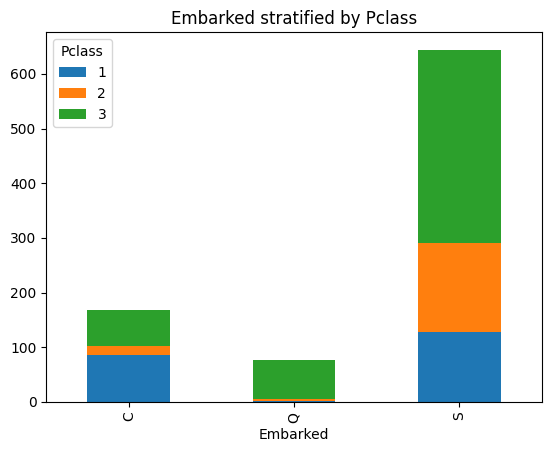

In [ ]:
#reset_index() per avere 'Embarked' come colonna
ct = pd.crosstab(df['Embarked'], df['Pclass']).reset_index()

ct.plot.bar(
    x='Embarked',
    stacked=True,
    title='Embarked stratified by Pclass'
)


#By observing the stratified bar plot, we can see that Queenstown was the city with the minor 
#number of emigrants, with only 100 departures against 180 from France and >600 from UK.
#But even with this lower number of departures, Queenstown had the highest percentage of third class
#passengers.

In [ ]:
#Check whether the 'Survived' attribute is correlated with 'Age', 'Fare', 
# 'SibSp', or	'Parch'.

df[['Survived', 'Age', 'Fare', 'SibSp', 'Parch']].corr()
#By this we see that survived is correlated with fare positively, and negatively or in a irrelevant 
#way with Age, SibSp e Parch.



,Survived,Age,Fare,SibSp,Parch
Survived,1.000000,-0.077221,0.257307,-0.035322,0.081629
Age,-0.077221,1.000000,0.096067,-0.308247,-0.189119
Fare,0.257307,0.096067,1.000000,0.159651,0.216225
SibSp,-0.035322,-0.308247,0.159651,1.000000,0.414838
Parch,0.081629,-0.189119,0.216225,0.414838,1.000000


In [ ]:
#Define a new column=Childen and compute correlation with survival.
df['Children'] = df['Age'] < 15
df[['Children', 'Survived']].corr()

#Looking at this correlation we can see that being a child is positvely correlated with survival, 
# even if the correlation is not that high, we can evince that being a child
# is a positive factor for survival.

,Children,Survived
Children,1.000000,0.122978
Survived,0.122978,1.000000


In [ ]:
df[['Survived', 'Pclass', 'Age']].corr()

#Survival is negatively correlated with both Pclass and Age
# which means lower class and higher age are negative factors for survival.

,Survived,Pclass,Age
Survived,1.000000,-0.338481,-0.077221
Pclass,-0.338481,1.000000,-0.369226
Age,-0.077221,-0.369226,1.000000


           Age      Fare
Age   1.000000  0.096067
Fare  0.096067  1.000000
Pearson  r = 0.0961, p-value = 0.01022
Spearman rho = 0.1351, p-value = 0.0002958
Kendall  tau = 0.0932, p-value = 0.0002449


/Users/chad/Desktop/Documenti/Uni/4_Anno/Big_Data_Analytics/BigData/Explorative_Data_Analysis/venv/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


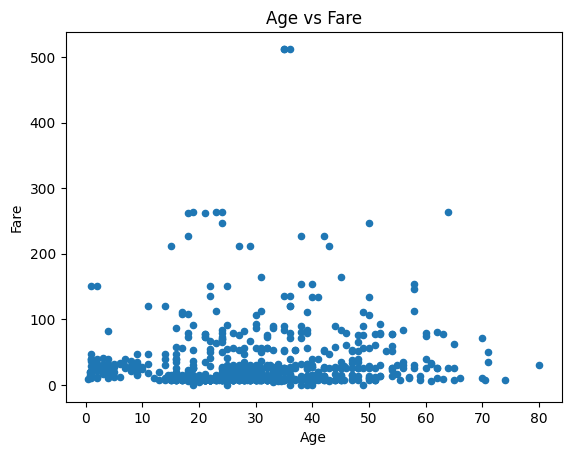

In [36]:
from scipy.stats import pearsonr, spearmanr, kendalltau

df.plot.scatter(x='Age', y='Fare', colormap='viridis', title='Age vs Fare')

age_fare = df[['Age', 'Fare']].dropna()
print(age_fare.corr())

pearson_corr, pearson_p = pearsonr(age_fare['Age'], age_fare['Fare'])
spearman_corr, spearman_p = spearmanr(age_fare['Age'], age_fare['Fare'])
kendall_corr, kendall_p = kendalltau(age_fare['Age'], age_fare['Fare'])

print(f'Pearson  r = {pearson_corr:.4f}, p-value = {pearson_p:.4g}')
print(f'Spearman rho = {spearman_corr:.4f}, p-value = {spearman_p:.4g}')
print(f'Kendall  tau = {kendall_corr:.4f}, p-value = {kendall_p:.4g}')